In [146]:
import pandas as pd

In [147]:
df = pd.read_csv("movie_reviews.csv")

In [148]:
df.head(50)

,movie,review
0,scary_movie_2026,Storyline was far from flowing and logical. De...
1,scary_movie_2026,Leave at the middle
2,scary_movie_2026,"20 minutes in, I already started hating the mo..."
3,scary_movie_2026,"Hilarious, they did a great job with this. Def..."
4,scary_movie_2026,It wasnt as funny as the others. I liked seein...
5,scary_movie_2026,Joke weren’t that funny
6,scary_movie_2026,"It was funny, the nostalgia was there. not as ..."
7,scary_movie_2026,This movie was great! I just wish that there w...
8,scary_movie_2026,Omg it's so bad. Didn't laugh once. And I'm a ...
9,scary_movie_2026,Had some laughs but some jokes didn’t land . W...


In [149]:
# remove duplicated reviews by checking the "review" column
df.drop_duplicates(subset="review", inplace=True)

In [150]:
df.shape

(301, 2)

In [151]:
df.to_csv("pre-processed_movie_reviews.csv", index=False)

In [152]:
df.shape

(301, 2)

# Data Cleaning

In [153]:
import re

In [154]:
def clean_text(text):

    text = str(text).lower()  # Convert to lowercase

    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation

    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # Remove URLs

    text = re.sub(r'\d+', '', text)  # Remove numbers

    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace

    text = re.sub(r'[^\x00-\x7F]+', '', text) # Remove non-ASCII characters

    return text.strip()

df['cleaned_review'] = df['review'].apply(clean_text)

In [155]:
df.head()

,movie,review,cleaned_review
0,scary_movie_2026,Storyline was far from flowing and logical. De...,storyline was far from flowing and logical def...
1,scary_movie_2026,Leave at the middle,leave at the middle
2,scary_movie_2026,"20 minutes in, I already started hating the mo...",minutes in i already started hating the movie ...
3,scary_movie_2026,"Hilarious, they did a great job with this. Def...",hilarious they did a great job with this defin...
4,scary_movie_2026,It wasnt as funny as the others. I liked seein...,it wasnt as funny as the others i liked seeing...


# Genarate labels

In [156]:
from textblob import TextBlob

In [157]:
def sentiment_label(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'
    
df['sentiment'] = df['cleaned_review'].apply(sentiment_label)

In [158]:
df.head()

,movie,review,cleaned_review,sentiment
0,scary_movie_2026,Storyline was far from flowing and logical. De...,storyline was far from flowing and logical def...,positive
1,scary_movie_2026,Leave at the middle,leave at the middle,neutral
2,scary_movie_2026,"20 minutes in, I already started hating the mo...",minutes in i already started hating the movie ...,negative
3,scary_movie_2026,"Hilarious, they did a great job with this. Def...",hilarious they did a great job with this defin...,positive
4,scary_movie_2026,It wasnt as funny as the others. I liked seein...,it wasnt as funny as the others i liked seeing...,positive


# Explonatory Data Analysis

In [159]:
from collections import Counter

In [160]:
words = " ".join(df["cleaned_review"]).split()
Counter(words).most_common(10)

[('the', 608),
 ('and', 352),
 ('a', 343),
 ('of', 222),
 ('it', 217),
 ('to', 209),
 ('i', 201),
 ('movie', 179),
 ('was', 167),
 ('is', 142)]

## Word Cloud

In [161]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

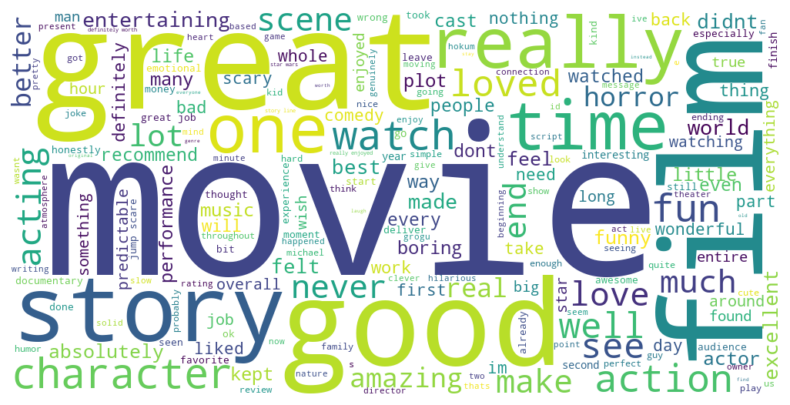

In [162]:
wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white').generate(" ".join(df["cleaned_review"]))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Tf-Idf model

In [163]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [164]:
vectorizer = TfidfVectorizer(
    max_features=5000, 
    stop_words='english'
)

x = vectorizer.fit_transform(df['cleaned_review'])
y = df['sentiment']

In [165]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [166]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [167]:
from sklearn.metrics import classification_report, confusion_matrix

pred = model.predict(X_test)

In [168]:
confusion_matrix(y_test, pred)

array([[ 0,  0, 11],
       [ 0,  0,  4],
       [ 0,  0, 46]])

In [169]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        11
     neutral       0.00      0.00      0.00         4
    positive       0.75      1.00      0.86        46

    accuracy                           0.75        61
   macro avg       0.25      0.33      0.29        61
weighted avg       0.57      0.75      0.65        61



C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

In [170]:
f1_score = classification_report(y_test, pred, output_dict=True)['positive']['f1-score']
print(f"F1 Score: {f1_score:.4f}") 

F1 Score: 0.8598


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

# BERT Model

In [171]:
df.head()

,movie,review,cleaned_review,sentiment
0,scary_movie_2026,Storyline was far from flowing and logical. De...,storyline was far from flowing and logical def...,positive
1,scary_movie_2026,Leave at the middle,leave at the middle,neutral
2,scary_movie_2026,"20 minutes in, I already started hating the mo...",minutes in i already started hating the movie ...,negative
3,scary_movie_2026,"Hilarious, they did a great job with this. Def...",hilarious they did a great job with this defin...,positive
4,scary_movie_2026,It wasnt as funny as the others. I liked seein...,it wasnt as funny as the others i liked seeing...,positive


In [172]:
label_map = {
    "positive": 1,
    "negative": 0,
    "neutral": 2
}

df['sentiment_label'] = df['sentiment'].map(label_map)

In [173]:
df.head()

,movie,review,cleaned_review,sentiment,sentiment_label
0,scary_movie_2026,Storyline was far from flowing and logical. De...,storyline was far from flowing and logical def...,positive,1
1,scary_movie_2026,Leave at the middle,leave at the middle,neutral,2
2,scary_movie_2026,"20 minutes in, I already started hating the mo...",minutes in i already started hating the movie ...,negative,0
3,scary_movie_2026,"Hilarious, they did a great job with this. Def...",hilarious they did a great job with this defin...,positive,1
4,scary_movie_2026,It wasnt as funny as the others. I liked seein...,it wasnt as funny as the others i liked seeing...,positive,1


In [174]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['cleaned_review'], 
    df['sentiment_label'],
    test_size=0.2,
    random_state=42
)


In [175]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [176]:
train_encodings = tokenizer(
    train_texts.tolist(), 
    truncation=True, 
    padding=True, 
    max_length=128
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [177]:
import torch

class reviewDataSet(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [178]:
train_dataset = reviewDataSet(train_encodings, train_labels)
test_dataset = reviewDataSet(test_encodings, test_labels)

In [179]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [180]:
# Training arguments
from transformers import TrainingArguments
from transformers import Trainer

_training_arg = TrainingArguments(
    output_dir='./results',          # output directory
    num_train_epochs=2,              # total number of training epochs
    per_device_train_batch_size=8,  # batch size per device during training
    per_device_eval_batch_size=8,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for storing logs
    logging_steps=10,
)

trainer = Trainer(
    model = model,
    args = _training_arg,
    train_dataset = train_dataset,
    eval_dataset = test_dataset
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# train bert save to results folder
trainer.train() 

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
10,1.514770
20,1.335566
30,1.215017
40,1.096141
50,0.970024
60,0.891094


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=60, training_loss=1.1704353173573812, metrics={'train_runtime': 300.5266, 'train_samples_per_second': 1.597, 'train_steps_per_second': 0.2, 'total_flos': 31573610127360.0, 'train_loss': 1.1704353173573812, 'epoch': 2.0})